## 지난주 개념 복습!
아래 마크다운을 풀고, 지난주 예습과제를 통해 공부한 Vision Transformer의 특징과 다른 모델들과의 차이점을 간략히 설명해주세요.

- ViT:이미지를 patch로 나눠서 tranformer로 이미지 처리.
- Swin Transformer: ViT의 계산량 문제를 해결하기 이해 이미지를 작은 window단위로 나눠서 attention수행. shifted widnow사용해서 정보교환. 메모리 효율 및 성능 증가
- CvT:convolution으로 지역 특징 추출 후 transformer로 전역 관계 학습.지역 특징 탐지성능 및 효율성 증가.

## 파이토치로 구현한 Vision Transformer
이번 복습과제에서는 카사바 잎 질병 데이터셋으로 vision transformer를 학습시키겠습니다.
- 첨부된 드라이브에서 필요한 파일들을 다운받을 수 있습니다.

In [1]:
!curl https://raw.githubusercontent.com/pytorch/xla/master/contrib/scripts/env-setup.py -o pytorch-xla-env-setup.py
!python pytorch-xla-env-setup.py --version 1.7
!pip install timm
!pip install torch_xla

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100    14  100    14    0     0     68      0 --:--:-- --:--:-- --:--:--    68
  File "/content/pytorch-xla-env-setup.py", line 1
    404: Not Found
    ^^^
SyntaxError: illegal target for annotation
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 MB 10.3 MB/s eta 0:00:00


### 데이터 불러오기

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#.zip 파일 unzip
#본인 드라이브의 경로에 맞게 수정해주세요!
!unzip /content/drive/MyDrive/Euron/train_images-002 -d /content/drive/MyDrive/Euron/train_images-002

Streaming output truncated to the last 5000 lines.
  inflating: /content/drive/MyDrive/Euron/train_images-002/3952546193.jpg  
  inflating: /content/drive/MyDrive/Euron/train_images-002/3952799769.jpg  
  inflating: /content/drive/MyDrive/Euron/train_images-002/3953140534.jpg  
  inflating: /content/drive/MyDrive/Euron/train_images-002/3953222407.jpg  
  inflating: /content/drive/MyDrive/Euron/train_images-002/3953247024.jpg  
  inflating: /content/drive/MyDrive/Euron/train_images-002/3953327881.jpg  
  inflating: /content/drive/MyDrive/Euron/train_images-002/3953331047.jpg  
  inflating: /content/drive/MyDrive/Euron/train_images-002/3953514366.jpg  
  inflating: /content/drive/MyDrive/Euron/train_images-002/3953530273.jpg  
  inflating: /content/drive/MyDrive/Euron/train_images-002/3953560426.jpg  
  inflating: /content/drive/MyDrive/Euron/train_images-002/3953648207.jpg  
  inflating: /content/drive/MyDrive/Euron/train_images-002/3953857113.jpg  
  inflating: /content/drive/MyDrive/E

In [24]:
#본인 드라이브의 경로에 맞게 수정해주세요!
!unzip /content/drive/MyDrive/Euron/jx_vit_base_p16_224-80ecf9dd.pth.zip -d /content/drive/MyDrive/Euron/mydata/

Archive:  /content/drive/MyDrive/Euron/jx_vit_base_p16_224-80ecf9dd.pth.zip
replace /content/drive/MyDrive/Euron/mydata/jx_vit_base_p16_224-80ecf9dd.pth? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: /content/drive/MyDrive/Euron/mydata/jx_vit_base_p16_224-80ecf9dd.pth  


In [2]:
#파일 경로
DATA_PATH = "/content/drive/MyDrive/Euron/mydata/"
TRAIN_PATH = "/content/drive/MyDrive/Euron/train_images-002/"
TEST_PATH = "/content/drive/MyDrive/Euron/mydata/test.jpg"
MODEL_PATH = (
    "/content/drive/MyDrive/Euron/mydata/jx_vit_base_p16_224-80ecf9dd.pth"
)

### 라이브러리

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("ggplot")

import torch
import torch.nn as nn
import torchvision.transforms as transforms

#import torch_xla
#import torch_xla.core.xla_model as xm
#import torch_xla.distributed.xla_multiprocessing as xmp
#import torch_xla.distributed.parallel_loader as pl
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

import timm

import gc
import os
import time
import random
from datetime import datetime

from PIL import Image
from tqdm.notebook import tqdm
from sklearn import model_selection, metrics

cuda


In [4]:
os.environ["XLA_USE_BF16"] = "1"
os.environ["XLA_TENSOR_ALLOCATOR_MAXSIZE"] = "100000000"

In [5]:
def seed_everything(seed):
    """
    Seeds basic parameters for reproductibility of results

    Arguments:
        seed {int} -- Number of the seed
    """
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


seed_everything(1001)

### 파라미터

In [6]:
IMG_SIZE = 224  #ViT에 적합한 이미지 크기로 설정해주세요.
BATCH_SIZE = 4
LR = 2e-05
GAMMA = 0.7
N_EPOCHS = 1  #모델 학습을 위해서는 더 많은 에포크가 필요하지만, 파일 크기가 큰 관계로 이번 과제에서는 전 과정을 한 번만 수행하겠습니다.

In [7]:
# pandas로 csv 파일을 읽은 뒤, 첫 5행을 출력하세요.
df = pd.read_csv(os.path.join(DATA_PATH, "train.csv"))
df.head()

,image_id,label
0,1000015157.jpg,0
1,1000201771.jpg,3
2,100042118.jpg,1
3,1000723321.jpg,1
4,1000812911.jpg,3


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21397 entries, 0 to 21396
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   image_id  21397 non-null  object
 1   label     21397 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 334.5+ KB


<Axes: xlabel='label'>

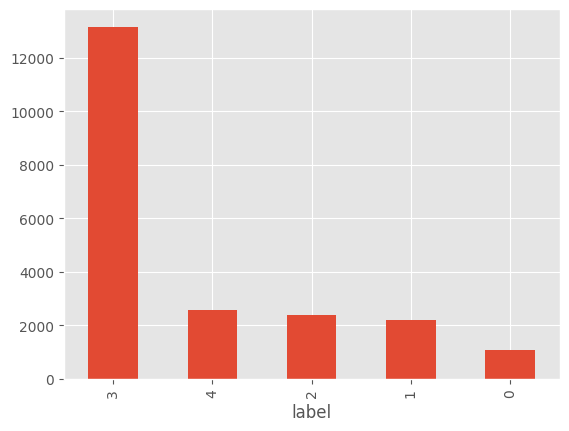

In [9]:
df.label.value_counts().plot(kind="bar")

In [10]:
# train과 test를 9:1로 나눠주세요.
# random_state은 자유롭게 지정 가능합니다.
train_df, valid_df = model_selection.train_test_split(
    df, test_size=0.1, random_state=42, stratify=df.label.values
)

In [11]:
class CassavaDataset(torch.utils.data.Dataset):

    def __init__(self, df, image_folder_path, transforms=None):
        super().__init__()
        self.df_data = df.values
        self.image_folder_path = image_folder_path
        self.transforms = transforms

    def __len__(self):
        return len(self.df_data)

    def __getitem__(self, index):
        img_name, label = self.df_data[index]
        img_path = os.path.join(self.image_folder_path, img_name)
        img = Image.open(img_path).convert("RGB")

        if self.transforms is not None:
            image = self.transforms(img)

        return image, label

In [12]:
#데이터 증강
transforms_train = transforms.Compose(
    [
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(p=0.3),
        transforms.RandomResizedCrop(IMG_SIZE),
        transforms.ToTensor(),
        transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
    ]
)

transforms_valid = transforms.Compose(
    [
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
    ]
)

In [13]:
#사용 가능한 ViT 모델 목록
##우리는 이중 vit_base_patch16_224를 사용합니다!
print("Available Vision Transformer Models: ")
timm.list_models("vit*")

Available Vision Transformer Models: 


['vit_7b_patch16_dinov3',
 'vit_base_mci_224',
 'vit_base_patch8_224',
 'vit_base_patch14_dinov2',
 'vit_base_patch14_reg4_dinov2',
 'vit_base_patch16_18x2_224',
 'vit_base_patch16_224',
 'vit_base_patch16_224_miil',
 'vit_base_patch16_384',
 'vit_base_patch16_clip_224',
 'vit_base_patch16_clip_384',
 'vit_base_patch16_clip_quickgelu_224',
 'vit_base_patch16_dinov3',
 'vit_base_patch16_dinov3_qkvb',
 'vit_base_patch16_gap_224',
 'vit_base_patch16_plus_240',
 'vit_base_patch16_plus_clip_240',
 'vit_base_patch16_reg4_gap_256',
 'vit_base_patch16_rope_224',
 'vit_base_patch16_rope_ape_224',
 'vit_base_patch16_rope_mixed_224',
 'vit_base_patch16_rope_mixed_ape_224',
 'vit_base_patch16_rope_reg1_gap_256',
 'vit_base_patch16_rpn_224',
 'vit_base_patch16_siglip_224',
 'vit_base_patch16_siglip_256',
 'vit_base_patch16_siglip_384',
 'vit_base_patch16_siglip_512',
 'vit_base_patch16_siglip_gap_224',
 'vit_base_patch16_siglip_gap_256',
 'vit_base_patch16_siglip_gap_384',
 'vit_base_patch16_siglip

### 모델 설계
- 클래스 ViTBase16의 각 줄을 설명하는 주석을 달아주세요. (최소 15개)

In [14]:
# 이 셀 안의 코드에 대해서 주석을 달아주세요.
class ViTBase16(nn.Module):
    def __init__(self, n_classes, pretrained=False):

        super(ViTBase16, self).__init__()

        self.model = timm.create_model("vit_base_patch16_224", pretrained=False)
        if pretrained:
            self.model.load_state_dict(torch.load(MODEL_PATH))

        self.model.head = nn.Linear(self.model.head.in_features, n_classes)

    def forward(self, x):
        x = self.model(x)
        return x

    def train_one_epoch(self, train_loader, criterion, optimizer, device):
        epoch_loss = 0.0
        epoch_accuracy = 0.0

        self.model.train()
        for i, (data, target) in enumerate(train_loader):
            if device.type == "cuda":
                data, target = data.cuda(), target.cuda()
            elif device.type == "xla":
                data = data.to(device, dtype=torch.float32)
                target = target.to(device, dtype=torch.int64)

            optimizer.zero_grad()
            output = self.forward(data)
            loss = criterion(output, target)
            loss.backward()
            accuracy = (output.argmax(dim=1) == target).float().mean()

            epoch_loss += loss
            epoch_accuracy += accuracy

            if device.type == "xla":
                xm.optimizer_step(optimizer)

                if i % 20 == 0:
                    xm.master_print(f"\tBATCH {i+1}/{len(train_loader)} - LOSS: {loss}")

            else:
                optimizer.step()

        return epoch_loss / len(train_loader), epoch_accuracy / len(train_loader)

    def validate_one_epoch(self, valid_loader, criterion, device):
        valid_loss = 0.0
        valid_accuracy = 0.0

        self.model.eval()
        for data, target in valid_loader:
            if device.type == "cuda":
                data, target = data.cuda(), target.cuda()
            elif device.type == "xla":
                data = data.to(device, dtype=torch.float32)
                target = target.to(device, dtype=torch.int64)

            with torch.no_grad():
                output = self.model(data)
                loss = criterion(output, target)
                accuracy = (output.argmax(dim=1) == target).float().mean()

                valid_loss += loss
                valid_accuracy += accuracy

        return valid_loss / len(valid_loader), valid_accuracy / len(valid_loader)

In [15]:
def fit_tpu(
    model, epochs, device, criterion, optimizer, train_loader, valid_loader=None
):

    valid_loss_min = np.inf

    train_losses = []
    valid_losses = []
    train_accs = []
    valid_accs = []

    for epoch in range(1, epochs + 1):
        gc.collect()
        para_train_loader = pl.ParallelLoader(train_loader, [device])

        xm.master_print(f"{'='*50}")
        xm.master_print(f"EPOCH {epoch} - TRAINING...")
        train_loss, train_acc = model.train_one_epoch(
            para_train_loader.per_device_loader(device), criterion, optimizer, device
        )
        xm.master_print(
            f"\n\t[TRAIN] EPOCH {epoch} - LOSS: {train_loss}, ACCURACY: {train_acc}\n"
        )
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        gc.collect()

        if valid_loader is not None:
            gc.collect()
            para_valid_loader = pl.ParallelLoader(valid_loader, [device])
            xm.master_print(f"EPOCH {epoch} - VALIDATING...")
            valid_loss, valid_acc = model.validate_one_epoch(
                para_valid_loader.per_device_loader(device), criterion, device
            )
            xm.master_print(f"\t[VALID] LOSS: {valid_loss}, ACCURACY: {valid_acc}\n")
            valid_losses.append(valid_loss)
            valid_accs.append(valid_acc)
            gc.collect()

            if valid_loss <= valid_loss_min and epoch != 1:
                xm.master_print(
                    "Validation loss decreased ({:.4f} --> {:.4f}).  Saving model ...".format(
                        valid_loss_min, valid_loss
                    )
                )

            valid_loss_min = valid_loss

    return {
        "train_loss": train_losses,
        "valid_losses": valid_losses,
        "train_acc": train_accs,
        "valid_acc": valid_accs,
    }

In [16]:
def fit(
    model, epochs, device, criterion, optimizer, train_loader, valid_loader=None
):

    valid_loss_min = np.inf

    train_losses = []
    valid_losses = []
    train_accs = []
    valid_accs = []

    for epoch in range(1, epochs + 1):
        gc.collect()

        print(f"{'='*50}")
        print(f"EPOCH {epoch} - TRAINING...")
        train_loss, train_acc = model.train_one_epoch(
            train_loader, criterion, optimizer, device
        )
        print(
            f"\n\t[TRAIN] EPOCH {epoch} - LOSS: {train_loss}, ACCURACY: {train_acc}\n"
        )
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        gc.collect()

        if valid_loader is not None:
            print(f"EPOCH {epoch} - VALIDATING...")

            valid_loss, valid_acc = model.validate_one_epoch(
                valid_loader, criterion, device
            )

            print(f"\t[VALID] LOSS: {valid_loss}, ACCURACY: {valid_acc}\n")

            valid_losses.append(valid_loss)
            valid_accs.append(valid_acc)

            if valid_loss <= valid_loss_min and epoch != 1:
                print(
                    "Validation loss decreased ({:.4f} --> {:.4f}). Saving model ...".format(
                        valid_loss_min, valid_loss
                    )
                )

            valid_loss_min = valid_loss

    return {
        "train_loss": train_losses,
        "valid_loss": valid_losses,
        "train_acc": train_accs,
        "valid_acc": valid_accs,
    }

In [17]:
model = ViTBase16(n_classes=5, pretrained=True)

In [18]:
#TPU사용 안하는 관계로 코드 수정
def _run():
    train_dataset = CassavaDataset(train_df, image_folder_path=TRAIN_PATH, transforms=transforms_train)
    valid_dataset = CassavaDataset(valid_df, image_folder_path=TRAIN_PATH, transforms=transforms_valid)
    '''
    train_sampler = torch.utils.data.distributed.DistributedSampler(
        train_dataset,
        num_replicas=xm.xrt_world_size(),
        rank=xm.get_ordinal(),
        shuffle=True,
    )

    valid_sampler = torch.utils.data.distributed.DistributedSampler(
        valid_dataset,
        num_replicas=xm.xrt_world_size(),
        rank=xm.get_ordinal(),
        shuffle=False,
    )
    '''

    train_loader = torch.utils.data.DataLoader(
        dataset=train_dataset,
        batch_size=BATCH_SIZE,
        #sampler=train_sampler,
        shuffle=True,
        drop_last=True,
        num_workers=2,
    )

    valid_loader = torch.utils.data.DataLoader(
        dataset=valid_dataset,
        batch_size=BATCH_SIZE,
        #sampler=valid_sampler,
        shuffle=False,
        drop_last=True,
        num_workers=2,
    )

    criterion = nn.CrossEntropyLoss()  #cross entropy loss로 설정.
    #device = xm.xla_device()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    #lr = LR * xm.xrt_world_size()
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    '''
    xm.master_print(f"INITIALIZING TRAINING ON {xm.xrt_world_size()} TPU CORES")
    start_time = datetime.now()
    xm.master_print(f"Start Time: {start_time}")

    logs = fit_tpu(
        model=model,
        epochs=N_EPOCHS,
        device=device,
        criterion=criterion,
        optimizer=optimizer,
        train_loader=train_loader,
        valid_loader=valid_loader,
    )

    xm.master_print(f"Execution time: {datetime.now() - start_time}")

    xm.master_print("Saving Model")
    xm.save(
        model.state_dict(), f'model_5e_{datetime.now().strftime("%Y%m%d-%H%M")}.pth'
    )
    '''
    print("INITIALIZING TRAINING ON CPU")
    start_time = datetime.now()
    print(f"Start Time: {start_time}")

    logs = fit(
        model=model,
        epochs=N_EPOCHS,
        device=device,
        criterion=criterion,
        optimizer=optimizer,
        train_loader=train_loader,
        valid_loader=valid_loader,
    )

    print(f"Execution time: {datetime.now() - start_time}")

    print("Saving Model")
    torch.save(
        model.state_dict(),
        f'model_5e_{datetime.now().strftime("%Y%m%d-%H%M")}.pth'
    )

    return logs

In [19]:
logs = _run()

INITIALIZING TRAINING ON CPU
Start Time: 2026-05-11 10:58:08.863306
EPOCH 1 - TRAINING...

	[TRAIN] EPOCH 1 - LOSS: 0.5263453125953674, ACCURACY: 0.81195467710495

EPOCH 1 - VALIDATING...
	[VALID] LOSS: 0.4530814290046692, ACCURACY: 0.84112149477005

Execution time: 1:17:08.028577
Saving Model


In [ ]:
# Training 시작
def _mp_fn(rank, flags):
    torch.set_default_tensor_type("torch.FloatTensor")
    a = _run()


# Run
FLAGS = {}
xmp.spawn(_mp_fn, args=(FLAGS,), nprocs=1, start_method="fork")